Random Seed: 999
OUT_DIR: ./cdcgan_mri_outputs\run_20260317_220220
Device: cuda:0
Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test  classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
num_classes: 4
Using ALL classes. Train: 5600 Test: 1600


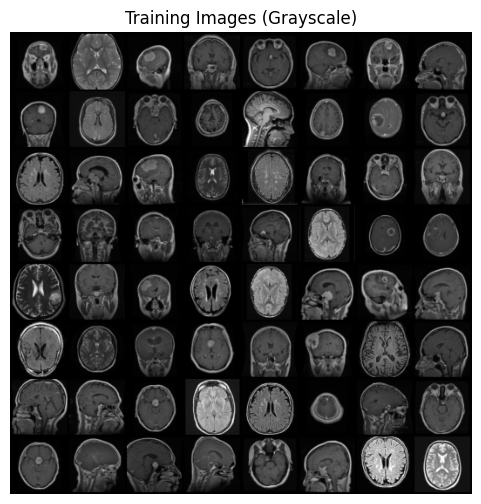

ConditionalGenerator(
  (embed): Embedding(4, 100)
  (main): Sequential(
    (0): ConvTranspose2d(200, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1,

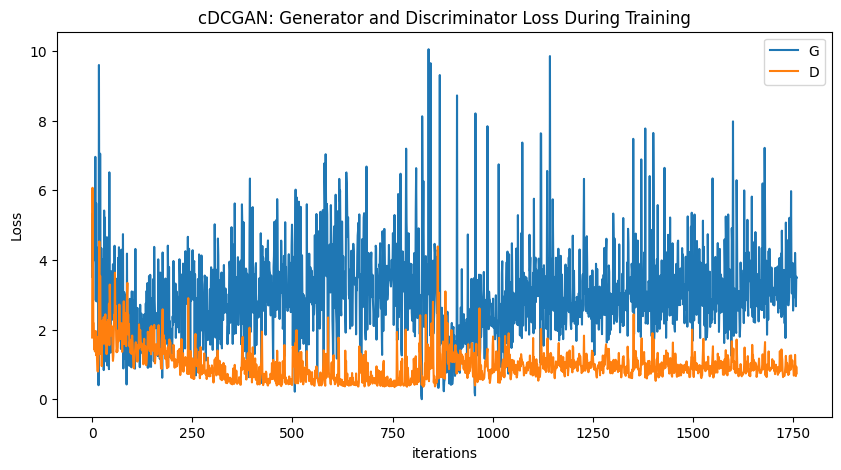

In [1]:
# =========================
# cDCGAN for Grayscale MRI (ImageFolder) 64x64
# - Conditional Generator: z + label
# - Conditional Discriminator: x + label_map
# =========================

import os, random, time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
from torch.utils.data import Subset
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import matplotlib.pyplot as plt

# -------------------------
# 0) Reproducibility (DON'T force deterministic for GAN)
# -------------------------
manualSeed = 999
print("Random Seed:", manualSeed)
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)

torch.use_deterministic_algorithms(False)
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

# -------------------------
# 1) Paths
# -------------------------
TRAIN_ROOT = r"C:\Users\22958\Desktop\毕业论文\archive\Training"
TEST_ROOT  = r"C:\Users\22958\Desktop\毕业论文\archive\Testing"

RUN_ID = time.strftime("run_%Y%m%d_%H%M%S")
OUT_DIR = os.path.join("./cdcgan_mri_outputs", RUN_ID)
os.makedirs(OUT_DIR, exist_ok=True)
print("OUT_DIR:", OUT_DIR)

# -------------------------
# 2) Hyperparameters
# -------------------------
workers = 0
batch_size = 64
image_size = 64
nc = 1
nz = 100
ngf = 64
ndf = 64
num_epochs = 20
beta1 = 0.5

# TTUR (often helps)
lrD = 2e-4
lrG = 2e-4

# ✅ 4类一起训：TARGET_CLASS=None
# ✅ 只训单类：例如 "notumor"
TARGET_CLASS = None  # None / "notumor" / "glioma" / "meningioma" / "pituitary"

DO_TEST_EVAL = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------------
# 3) Dataset & DataLoader
# -------------------------
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize(image_size),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_full = dset.ImageFolder(root=TRAIN_ROOT, transform=transform)
test_full  = dset.ImageFolder(root=TEST_ROOT,  transform=transform)

print("Train classes:", train_full.classes)
print("Test  classes:", test_full.classes)
assert train_full.classes == test_full.classes, "Train/Test class order mismatch!"

num_classes = len(train_full.classes)
print("num_classes:", num_classes)

def filter_one_class(ds: dset.ImageFolder, class_name: str):
    idx = ds.class_to_idx[class_name]
    keep = [i for i, (_, y) in enumerate(ds.samples) if y == idx]
    return Subset(ds, keep)

if TARGET_CLASS is not None:
    train_set = filter_one_class(train_full, TARGET_CLASS)
    test_set  = filter_one_class(test_full,  TARGET_CLASS)
    print(f"Filtered TRAIN to '{TARGET_CLASS}':", len(train_set))
    print(f"Filtered TEST  to '{TARGET_CLASS}':", len(test_set))
else:
    train_set = train_full
    test_set  = test_full
    print("Using ALL classes. Train:", len(train_set), "Test:", len(test_set))

train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True,
    num_workers=workers, pin_memory=(device.type == "cuda")
)

test_loader = torch.utils.data.DataLoader(
    test_set, batch_size=batch_size, shuffle=False,
    num_workers=workers, pin_memory=(device.type == "cuda")
)

# -------------------------
# 4) Visualize a batch
# -------------------------
real_batch = next(iter(train_loader))
plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Training Images (Grayscale)")
grid = vutils.make_grid(real_batch[0][:64], padding=2, normalize=True)
plt.imshow(grid[0], cmap="gray")
plt.show()

# -------------------------
# 5) Weight init
# -------------------------
def weights_init(m):
    cname = m.__class__.__name__
    if "Conv" in cname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in cname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

# -------------------------
# 6) Models (cDCGAN)
# -------------------------
class ConditionalGenerator(nn.Module):
    """
    z: [B, nz, 1, 1]
    y: [B] (class index)
    Use embedding(y) -> [B, embed_dim, 1, 1] then concat with z.
    """
    def __init__(self, nz, ngf, nc, num_classes, embed_dim=100):
        super().__init__()
        self.embed = nn.Embedding(num_classes, embed_dim)

        in_ch = nz + embed_dim
        self.main = nn.Sequential(
            nn.ConvTranspose2d(in_ch, ngf*8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*8), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*8, ngf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*4), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2), nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf), nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z, y):
        y_emb = self.embed(y).unsqueeze(2).unsqueeze(3)  # [B, embed_dim, 1, 1]
        x = torch.cat([z, y_emb], dim=1)                 # [B, nz+embed_dim, 1, 1]
        return self.main(x)

class ConditionalDiscriminator(nn.Module):
    """
    x: [B, nc, H, W]
    y: [B]
    Make label map: embed(y)->[B, H*W] -> reshape [B,1,H,W], then concat with x.
    """
    def __init__(self, ndf, nc, num_classes, image_size):
        super().__init__()
        self.image_size = image_size
        self.embed = nn.Embedding(num_classes, image_size*image_size)

        in_ch = nc + 1  # image + label_map
        self.main = nn.Sequential(
            nn.Conv2d(in_ch, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, ndf*8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*8, 1, 4, 1, 0, bias=False)  # logits
        )

    def forward(self, x, y):
        b = x.size(0)
        y_map = self.embed(y).view(b, 1, self.image_size, self.image_size)
        x_in = torch.cat([x, y_map], dim=1)           # [B, nc+1, H, W]
        logits = self.main(x_in).view(-1)            # [B]
        return logits

netG = ConditionalGenerator(nz=nz, ngf=ngf, nc=nc, num_classes=num_classes, embed_dim=100).to(device)
netD = ConditionalDiscriminator(ndf=ndf, nc=nc, num_classes=num_classes, image_size=image_size).to(device)
netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

# -------------------------
# 7) Loss & Optimizers
# -------------------------
criterion = nn.BCEWithLogitsLoss()

# fixed noise + fixed labels（方便你看每个类有没有变清晰）
fixed_noise = torch.randn(64, nz, 1, 1, device=device)
fixed_labels = torch.arange(num_classes, device=device).repeat(64 // num_classes + 1)[:64]

real_label_D = 0.9
fake_label   = 0.0

optimizerD = optim.Adam(netD.parameters(), lr=lrD, betas=(beta1, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lrG, betas=(beta1, 0.999))

# -------------------------
# 8) Optional TEST eval (sanity)
# -------------------------
@torch.no_grad()
def eval_D_real_fake(netG, netD, loader):
    netG.eval(); netD.eval()
    loss_sum, correct, total = 0.0, 0, 0

    for real_imgs, y_real_cls in loader:
        real_imgs = real_imgs.to(device)
        y_real_cls = y_real_cls.to(device)
        b = real_imgs.size(0)

        # real
        y_real = torch.ones(b, device=device)
        logits_real = netD(real_imgs, y_real_cls)
        loss_real = criterion(logits_real, y_real)

        # fake (random labels)
        y_fake_cls = torch.randint(0, num_classes, (b,), device=device)
        z = torch.randn(b, nz, 1, 1, device=device)
        fake_imgs = netG(z, y_fake_cls)

        y_fake = torch.zeros(b, device=device)
        logits_fake = netD(fake_imgs, y_fake_cls)
        loss_fake = criterion(logits_fake, y_fake)

        loss_sum += (loss_real + loss_fake).item() * b

        prob_real = torch.sigmoid(logits_real)
        prob_fake = torch.sigmoid(logits_fake)
        pred_real = (prob_real > 0.5).float()
        pred_fake = (prob_fake < 0.5).float()
        correct += pred_real.sum().item() + pred_fake.sum().item()
        total += 2 * b

    return loss_sum / len(loader.dataset), correct / total

# -------------------------
# 9) Training Loop
# -------------------------
G_losses, D_losses = [], []
iters = 0

print("Starting Training Loop...")
for epoch in range(num_epochs):
    netG.train(); netD.train()

    for i, (real_imgs, y_cls) in enumerate(train_loader):
        real_imgs = real_imgs.to(device)
        y_cls = y_cls.to(device)
        b = real_imgs.size(0)

        # ---------------------
        # (1) Update D
        # ---------------------
        netD.zero_grad()

        y_real = torch.full((b,), real_label_D, device=device)
        logits_real = netD(real_imgs, y_cls)
        errD_real = criterion(logits_real, y_real)
        errD_real.backward()

        # fake: 用随机标签训练更稳（覆盖所有类）
        y_fake_cls = torch.randint(0, num_classes, (b,), device=device)
        z = torch.randn(b, nz, 1, 1, device=device)
        fake = netG(z, y_fake_cls)

        y_fake = torch.full((b,), fake_label, device=device)
        logits_fake = netD(fake.detach(), y_fake_cls)
        errD_fake = criterion(logits_fake, y_fake)
        errD_fake.backward()

        errD = errD_real + errD_fake
        optimizerD.step()

        # ---------------------
        # (2) Update G
        # ---------------------
        netG.zero_grad()

        y_g_cls = torch.randint(0, num_classes, (b,), device=device)
        z2 = torch.randn(b, nz, 1, 1, device=device)
        fake2 = netG(z2, y_g_cls)

        y_g = torch.ones(b, device=device)  # non-saturating
        logits_g = netD(fake2, y_g_cls)
        errG = criterion(logits_g, y_g)
        errG.backward()
        optimizerG.step()

        G_losses.append(errG.item())
        D_losses.append(errD.item())

        if i % 50 == 0:
            Dx = torch.sigmoid(logits_real).mean().item()
            Dgz = torch.sigmoid(logits_fake).mean().item()
            print(f"[{epoch+1}/{num_epochs}][{i}/{len(train_loader)}] "
                  f"Loss_D: {errD.item():.4f} Loss_G: {errG.item():.4f} "
                  f"D(x): {Dx:.4f} D(G(z)): {Dgz:.4f}")

        # ---------------------
        # Save samples
        # ---------------------
        if (iters % 200 == 0) or ((epoch == num_epochs - 1) and (i == len(train_loader) - 1)):
            netG.eval()
            with torch.no_grad():
                fake_fixed = netG(fixed_noise, fixed_labels).detach().cpu()
                rand_labels = torch.randint(0, num_classes, (64,), device=device)
                rand_noise = torch.randn(64, nz, 1, 1, device=device)
                fake_rand = netG(rand_noise, rand_labels).detach().cpu()
            netG.train()

            vutils.save_image(fake_fixed, os.path.join(OUT_DIR, f"fixed_e{epoch+1}_i{iters}.png"),
                              normalize=True, nrow=8)
            vutils.save_image(fake_rand, os.path.join(OUT_DIR, f"rand_e{epoch+1}_i{iters}.png"),
                              normalize=True, nrow=8)
            print("Saved samples at iter", iters)

        iters += 1

    # ---- test eval (sanity) ----
    if DO_TEST_EVAL:
        test_lossD, test_accD = eval_D_real_fake(netG, netD, test_loader)
        print(f"[TEST] epoch {epoch+1}/{num_epochs}  D_loss={test_lossD:.4f}  D_acc={test_accD:.4f}")

    torch.save(netG.state_dict(), os.path.join(OUT_DIR, f"netG_epoch{epoch+1}.pth"))
    torch.save(netD.state_dict(), os.path.join(OUT_DIR, f"netD_epoch{epoch+1}.pth"))

# -------------------------
# 10) Plot loss curves
# -------------------------
plt.figure(figsize=(10, 5))
plt.title("cDCGAN: Generator and Discriminator Loss During Training")
plt.plot(G_losses, label="G")
plt.plot(D_losses, label="D")
plt.xlabel("iterations")
plt.ylabel("Loss")
plt.legend()
plt.show()

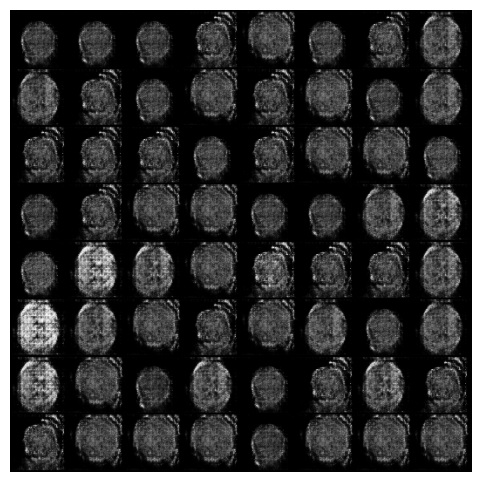

In [2]:
@torch.no_grad()
def show_grid_cdcgan(netG, nz, device, num_classes, n=64):
    netG.eval()
    z = torch.randn(n, nz, 1, 1, device=device)
    y = torch.randint(0, num_classes, (n,), device=device)
    fake = netG(z, y).cpu()

    grid = vutils.make_grid(fake, nrow=8, normalize=True)
    plt.figure(figsize=(6,6))
    plt.axis("off")
    plt.imshow(grid[0], cmap="gray")
    plt.show()

show_grid_cdcgan(netG, nz, device, num_classes)